# 01 - Quickstart: Running a Transdermal Diffusion Simulation

This notebook walks through a **single simulation** of the V3 literature-informed
model to illustrate the core pipeline: load a YAML config, run the finite-difference
solver, and visualize the concentration field, flux curve, and summary scalars.

The V3 model includes three anatomical skin layers (stratum corneum, viable epidermis,
dermis) with literature-constrained diffusivities and correlated spatial heterogeneity.

For consistency with the final project pipeline, this quickstart uses the clearance-aware
V3 base config. This notebook is a demonstration run; final surrogate comparison metrics
and timing are taken from the saved final artefacts in `results/ml/final`.

## Governing Model (PDE + BC/IC)

This equation is the engine of the simulator. It says concentration changes because drug spreads through tissue (diffusion) and can be removed locally (clearance).

Let $C(z, x, t)$ be concentration in a 2D skin domain (depth $z$, lateral coordinate $x$):

$$\frac{\partial C}{\partial t} = \nabla \cdot \left(D(z, x) \nabla C\right) - k(z, x) C$$

- $\partial C/\partial t$: how quickly concentration changes at each point.
- $\nabla \cdot (D\nabla C)$: diffusion from high concentration to low concentration.
- $-kC$: local loss (clearance), so concentration can decrease even without leaving the domain.

Initial condition:

We start from a clean state: before patch application, there is no drug inside the skin domain

$$C(z, x, 0) = 0$$

Boundary conditions used in this project:
These boundaries define how the skin interacts with its surroundings: drug enters where the patch is, does not enter where skin is uncovered, is removed at the receptor side, and does not leak through side walls.

- Top boundary, on patch: $C(0, x, t) = C_d(t)$ -> the patch acts like a concentration reservoir touching the skin.
- Top boundary, off patch: $\partial C/\partial z = 0$ (no vertical flux) -> no drug enters from uncovered skin.
- Bottom boundary (receptor sink): $C(H, x, t) = 0$ -> drug that reaches the receptor side is removed immediately.
- Lateral boundaries: $\partial C/\partial x = 0$ (no side flux) -> no artificial loss through left/right domain edges.

For finite-dose runs (V3), donor concentration decays as:

$$C_d(t) = C_0 e^{-\lambda t}$$

In finite-dose mode, the patch does not supply drug forever. The exponential term models reservoir depletion, so the driving concentration weakens over time.
For infinite-dose runs (V1/V2), $C_d(t)$ is constant.

### Symbol guide

- $C$: concentration field (mg/cm$^3$)
- $D$: diffusion coefficient (cm$^2$/s)
- $k$: first-order clearance rate (s$^{-1}$)
- $C_0$: initial donor concentration
- $\lambda$: donor depletion rate in finite-dose runs
- $H$: full skin depth in the simulation domain


## Numerical Scheme And Stability

The solver uses explicit finite-difference time stepping with a conservative variable-diffusivity operator:

$$C^{n+1} = C^n + \Delta t \left[\nabla \cdot (D \nabla C) - kC\right]^n$$

This is the computable form of the PDE. At each time step, we update concentration using the current diffusion and clearance terms.

The conservative flux form is important in layered media, where $D$ changes sharply between layers.
It keeps interface transport physically consistent.

Practical stability constraints checked in run metadata:
- diffusion-limited step size: $\Delta t = \mathcal{O}(\Delta x^2 / D_{\max})$
- reaction-limited step size: $\Delta t = \mathcal{O}(1/k_{\max})$

Explicit schemes are fast but only safe with small enough time steps. These limits make sure the update remains numerically stable and physically sensible.


## Literature Basis For Modeling Choices

This notebook follows modeling choices supported by literature and used throughout the project:
- Fickian layered transport with barrier-dominant stratum corneum behavior (Prausnitz and Langer, 2008).
- Human-skin lidocaine permeability and lag-time targets for calibration (Adamiak-Giera et al., 2023).
- Diffusion-equation benchmark framing and finite-slab reference theory (Crank, 1975).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

from skin_diffusion.notebook_helpers import setup_repo_root
from skin_diffusion.config import load_config
from skin_diffusion.run_utils import run_simulation

repo_root = setup_repo_root()

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'font.size': 10,
    'legend.fontsize': 9,
})

print('Setup complete OK')

Setup complete OK


## Load config & run simulation

We load the clearance-aware V3 literature-informed base config, which simulates
24 hours of transdermal diffusion through a layered skin model.

In [2]:
cfg = load_config('configs/sim/v3_layers_literature_clearance.yaml')
C_snap, t_save, D_field, k_field, patch_mask, diag, metrics, stab = run_simulation(cfg)

print(f'Grid shape: {C_snap.shape[1:]} (depth x x-index)')
print(f'Snapshots: {C_snap.shape[0]} time points over {t_save[-1]/3600:.0f} h')
print(f'D range: [{D_field.min():.2e}, {D_field.max():.2e}] cm^2/s')
print(f'Layers: SC (rows 0-0), VE (rows 1-9), Dermis (rows 10-63)')
print(f'Stability info: {stab}')

simulate: 100%|██████████| 432001/432001 [00:30<00:00, 14081.15it/s]

Grid shape: (64, 64) (depth x x-index)
Snapshots: 1441 time points over 24 h
D range: [1.16e-09, 2.32e-07] cm^2/s
Layers: SC (rows 0-0), VE (rows 1-9), Dermis (rows 10-63)
Stability info: {'Dmax': 2.32348986647243e-07, 'dt_diff_max': 0.6886193148882344, 'kmax': 3.3e-05, 'dt_react_max': 30303.0303030303}


## Concentration heatmaps

Snapshots at selected times show the drug front propagating from the patch (top)
through the stratum corneum, viable epidermis, and dermis.

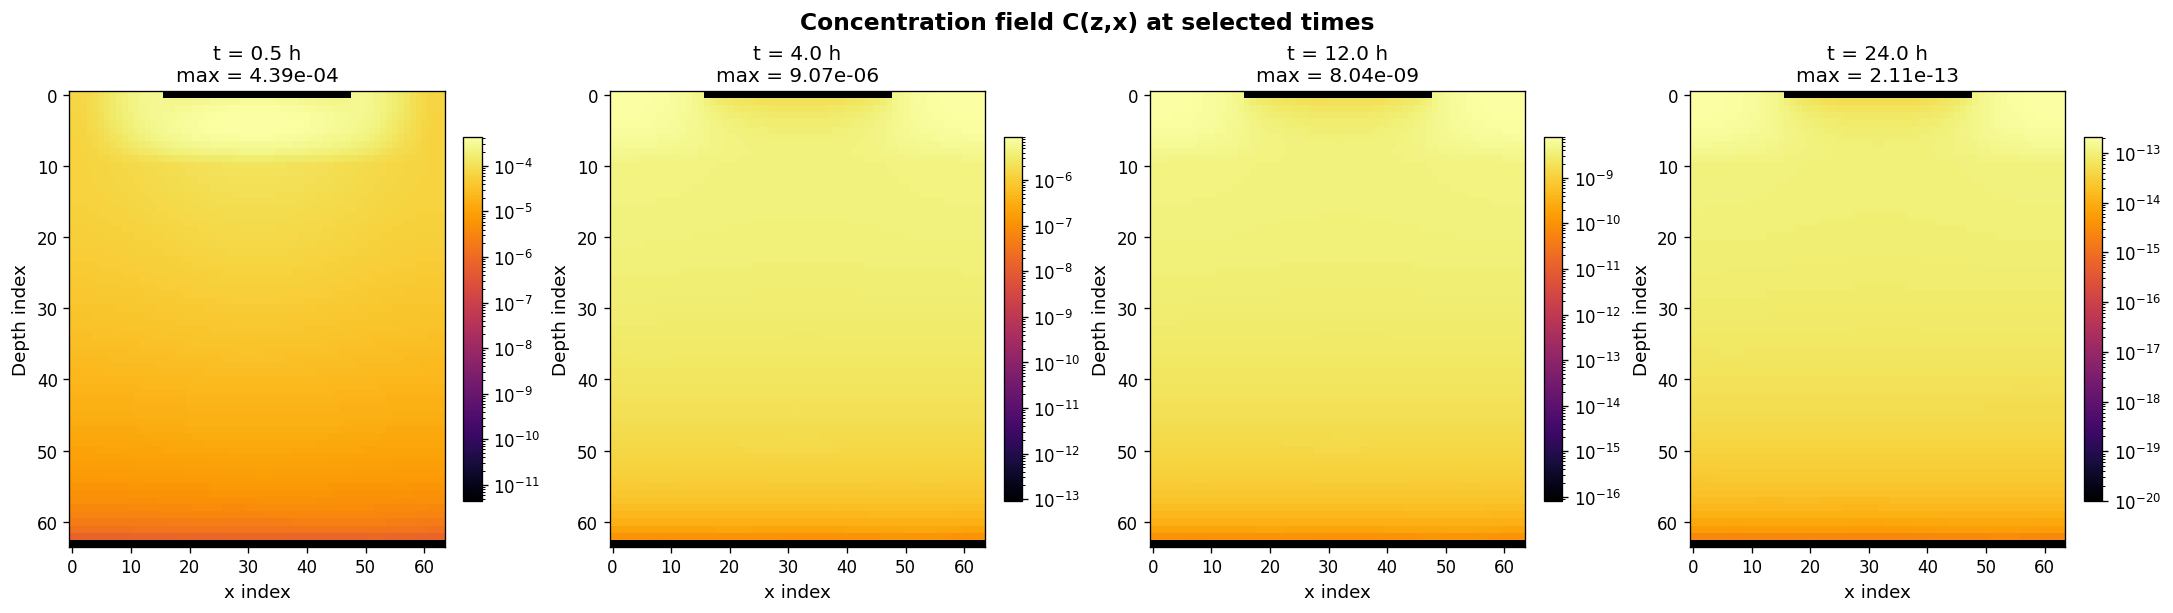

In [3]:
# Pick 4 time snapshots: early, mid, late, end
t_hours = t_save / 3600
snap_times_h = [0.5, 4, 12, 24]
snap_idx = [np.argmin(np.abs(t_hours - t)) for t in snap_times_h]

fig, axes = plt.subplots(1, 4, figsize=(18, 5), constrained_layout=True)
fig.suptitle('Concentration field C(z,x) at selected times',
             fontsize=14, fontweight='bold')

for ax, idx in zip(axes, snap_idx):
    data = C_snap[idx]
    # Per-panel normalization: floor at 1e-8 * panel max to show spatial structure
    panel_max = data.max()
    panel_floor = max(panel_max * 1e-8, 1e-20)
    data_plot = np.where(data > panel_floor, data, panel_floor)
    im = ax.imshow(data_plot, aspect='auto', origin='upper',
                   norm=LogNorm(vmin=panel_floor, vmax=panel_max),
                   cmap='inferno')
    ax.set_title(f't = {t_hours[idx]:.1f} h\nmax = {panel_max:.2e}')
    ax.set_xlabel('x index')
    ax.set_ylabel('Depth index')
    fig.colorbar(im, ax=ax, shrink=0.8)

plt.show()

**Concentration heatmaps at 0.5, 4, 12 and 24 hours.**
Each panel uses its own log-normalized color scale (color bars are not directly comparable in absolute magnitude).

- **t = 0.5 h** — Drug is concentrated beneath the patch with a steep near-surface gradient.
- **t = 4 h** — The diffusion front has penetrated deeper into tissue and spread laterally.
- **t = 12 h** — Concentration decreases substantially as the finite-dose donor decays.
- **t = 24 h** — Late-time field shows broad depletion relative to early-time frames.

This panel is best for spatial pattern interpretation over time rather than direct cross-panel magnitude comparison.


## Flux curve and scalar summary

### Flux And Scalar Definitions Used In This Notebook

Bottom-boundary flux is computed from the concentration gradient:

$$J(t) = -D \left.\frac{\partial C}{\partial z}\right|_{z=H}$$

- The minus sign in $J(t)$ only sets direction convention.
- Larger boundary gradient means larger flux (faster delivery rate).

Flux ($J(T)$) is the delivery rate crossing the bottom boundary. It links internal concentration gradients to outward drug transport.

Reported scalar endpoints:
- $J_{\mathrm{peak}} = \max_t J(t)$ : maximum delivery rate achieved.
- $t_{\mathrm{peak}} = \arg\max_t J(t)$ : when that maximum happens.
- $M_{\mathrm{delivered,24h}} = \int_0^{24h} J(t)\,dt$ : total amount delivered over 24 h (area under flux curve).
- $P = J_{\mathrm{ss}}/C_0$ : permeability-style summary linking flux to donor strength.
    - (mainly meaningful in near-steady or infinite-dose settings, so secondary in V3 finite-dose analysis)
- $T_{\mathrm{lag}}$: onset delay before substantial permeation from linear extrapolation of cumulative delivered mass
    - (reported as a secondary quantity in this project's V3 finite-dose setting)

These scalars summarize the full flux curve into clinically interpretable quantities while preserving the full $J(t)$ curve for detailed comparison.

## Diffusivity field

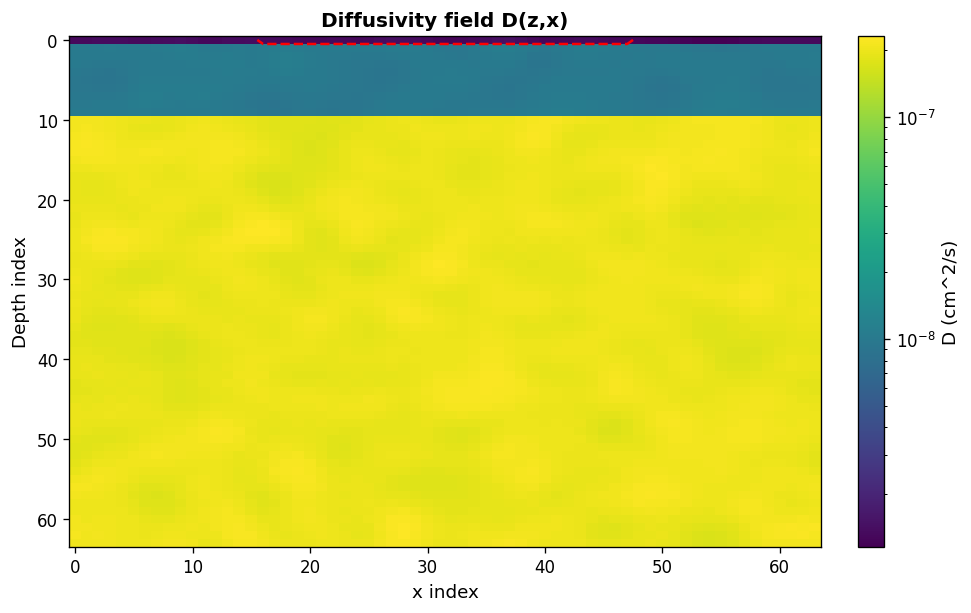

In [5]:
fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)

im = ax.imshow(D_field, aspect='auto', origin='upper',
               norm=LogNorm(), cmap='viridis')
fig.colorbar(im, ax=ax, label='D (cm^2/s)')
ax.set_xlabel('x index')
ax.set_ylabel('Depth index')
ax.set_title('Diffusivity field D(z,x)', fontweight='bold')

# Overlay patch mask outline
if patch_mask is not None:
    ax.contour(patch_mask.astype(float), levels=[0.5],
               colors='red', linewidths=1.5, linestyles='--')

plt.show()

**Spatially varying diffusivity field $D(z, x)$.**
The heatmap shows the diffusion coefficient on a log color scale.

- **Stratum corneum (top layer):** lowest diffusivity, acting as the dominant barrier.
- **Viable epidermis (middle layer):** intermediate diffusivity.
- **Dermis (lower layer):** highest diffusivity.

Subtle intra-layer texture reflects correlated heterogeneity in V3.
The red dashed contour marks the patch footprint on the top boundary.
